# PREDICTION DE LA REUSSITE SCOLAIRE

## 1. IMPORT DES LIBRAIRIES

In [539]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.tree import DecisionTreeClassifier, plot_tree
from scipy.stats import norm, skew, kurtosis
import scipy.stats as stats
%matplotlib inline

## 2. CHARGEMENT DES DONNÉES

## Import des jeux de données bruts

In [540]:
raw_mat = pd.read_csv("./data/raw_mat.csv", sep=";")
raw_por = pd.read_csv("./data/raw_por.csv", sep=";")

## Fusion des jeux de données

In [541]:
raw_mat["source"] = "mat"
raw_por["source"] = "por"

merged = pd.concat([raw_mat, raw_por])
merged.to_csv("data/merged.csv", index=False)

## 3. EXPLORATION DES DONNÉES

## Colonnes

In [542]:
merged.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,source
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


### Données personnelles et familiales

- **school :** École fréquentée : GP (Gabriel Pereira) ou MS (Mousinho
da Silveira)
- **sex :** Sexe de l’élève : F (fille) ou M (garçon)
- **age :** Âge de l’élève (entre 15 et 22 ans)
- **address :** Type d’habitation : U (urbain) ou R (rural)
- **famsize :** Taille de la famille : LE3 (≤3) ou GT3 (>3) personnes
- **Pstatus :** Statut marital des parents : T (ensemble) ou A (séparés)
- **Medu :** Niveau d’éducation de la mère (0 à 4)
- **Fedu :** Niveau d’éducation du père (0 à 4)
- **Mjob :** Profession de la mère (enseignant, santé, services, à domicile, autre)
- **Fjob :** Profession du père (idem Mjob)
- **reason :** Raison du choix de l’école : proximité, réputation, etc.
- **guardian :** Tuteur/tutrice principal(e) : mère, père ou autre

### Contexte scolaire et extra-scolaire

- **traveltime :** Temps de trajet domicile-école (1= <15 min, 4= >1h)
- **studytime :** Temps d’étude hebdo (1= <2h, 4= >10h)
- **failures :** Nb d’échecs passés (1 si jamais redoublé, 4 si 3 redoublements ou plus)
- **schoolsup :** Soutien scolaire supplémentaire (yes/no)
- **famsup :** Soutien familial (yes/no)
- **paid :** Cours payants en maths (yes/no)
- **activities :** Activités extrascolaires (yes/no)
- **nursery :** Fréquentation d’une maternelle (yes/no)
- **higher :** Souhait de poursuivre des études supérieures (yes/no)
- **internet :** Accès à internet à la maison (yes/no)
- **romantic :** En couple ou non (yes/no)

### Vie quotidienne

- **famrel :** Qualité des relations familiales (1= très mauvaise, 5=
excellente)
- **freetime :** Temps libre après l’école (1 à 5)
- **goout :** Fréquence des sorties avec des amis (1 à 5)
- **Dalc :** Consommation d’alcool en semaine (1= très faible, 5=
très élevée)
- **Walc :** Consommation d’alcool le week-end (1 à 5)
- **health :** État de santé (1= très mauvais, 5= excellent)
- **absences :** Nombre d’absences scolaires

### Résultats scolaires

- **G1 :** Note au premier trimestre (0 à 20)
- **G2 :** Note au second trimestre (0 à 20)
- **G3 :** Note finale (0 à 20) — variable cible
- **source :** Source du fichier : mat ou por (mathématiques ou
portugais)

In [543]:
merged.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 4. VISUALISATIONS

## Données manquantes

<Axes: >

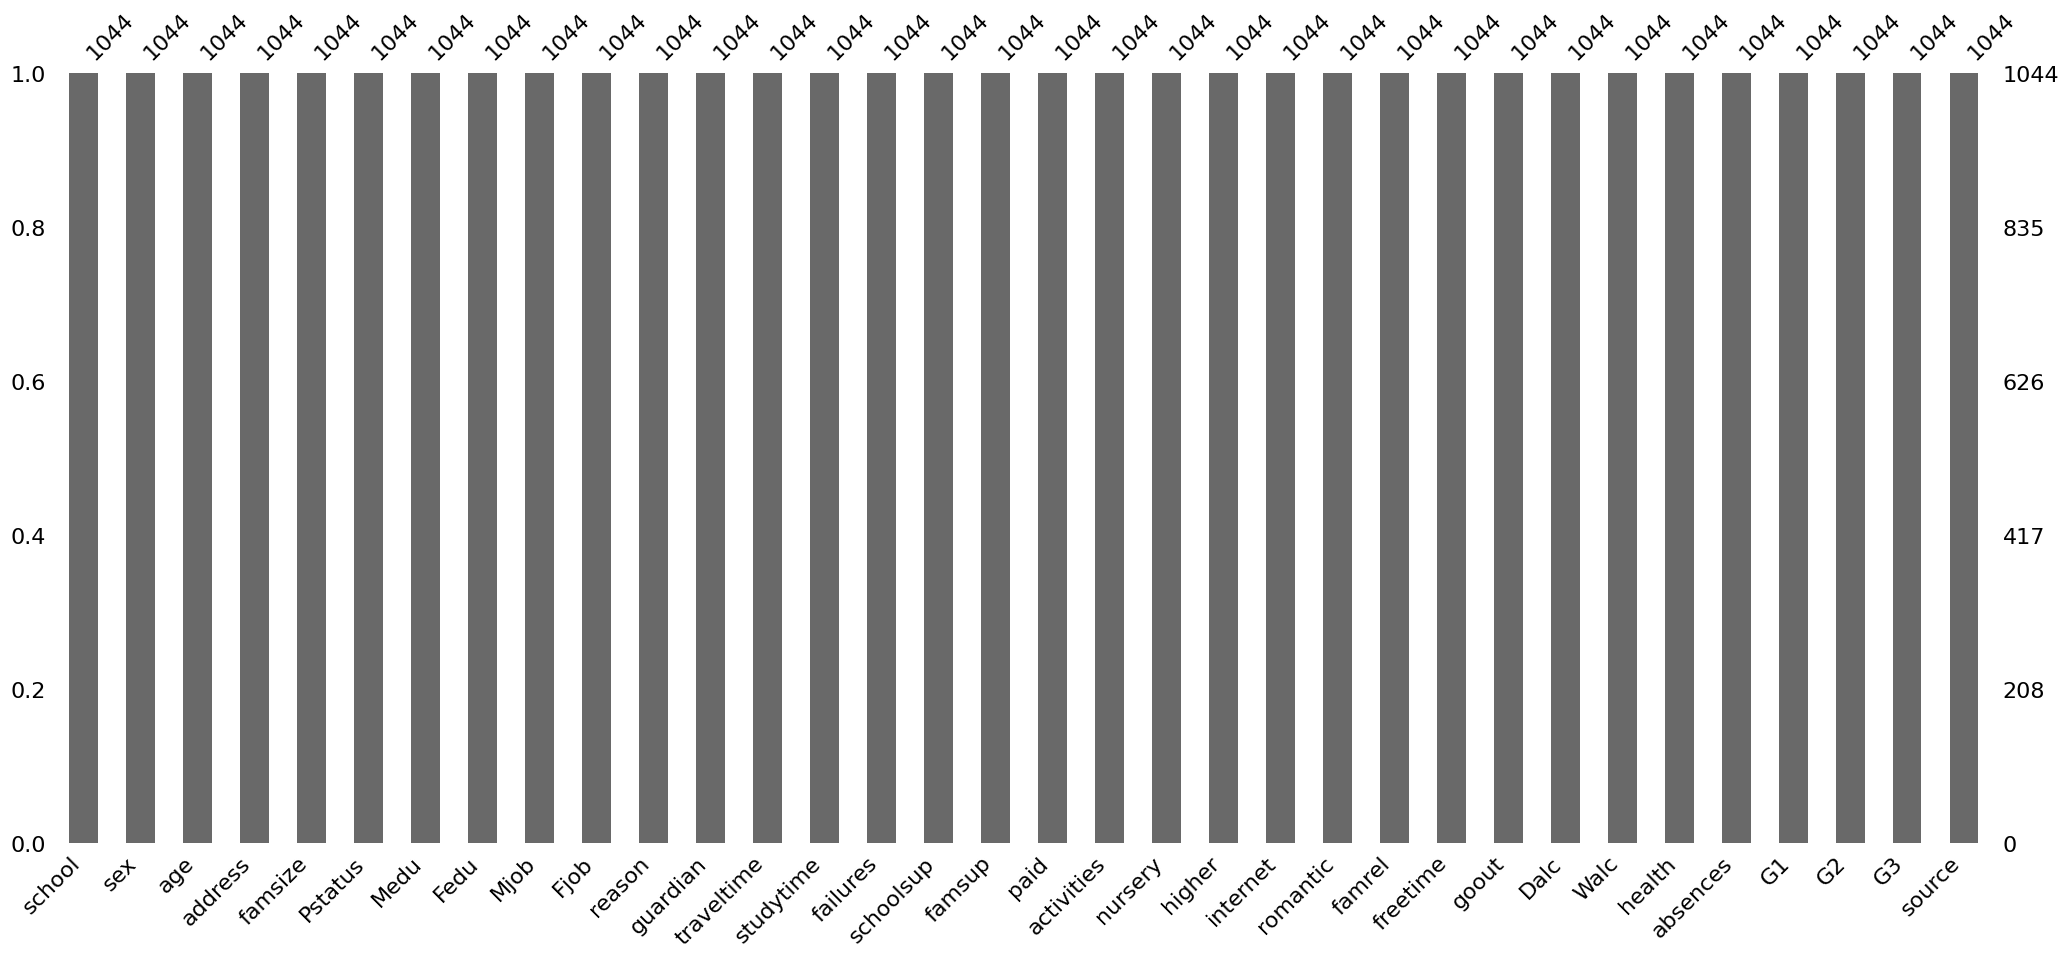

In [544]:
msno.bar(merged)

Nous pouvons constater que toutes les colonnes sont entièrement remplies.

## Corrélations

<Axes: >

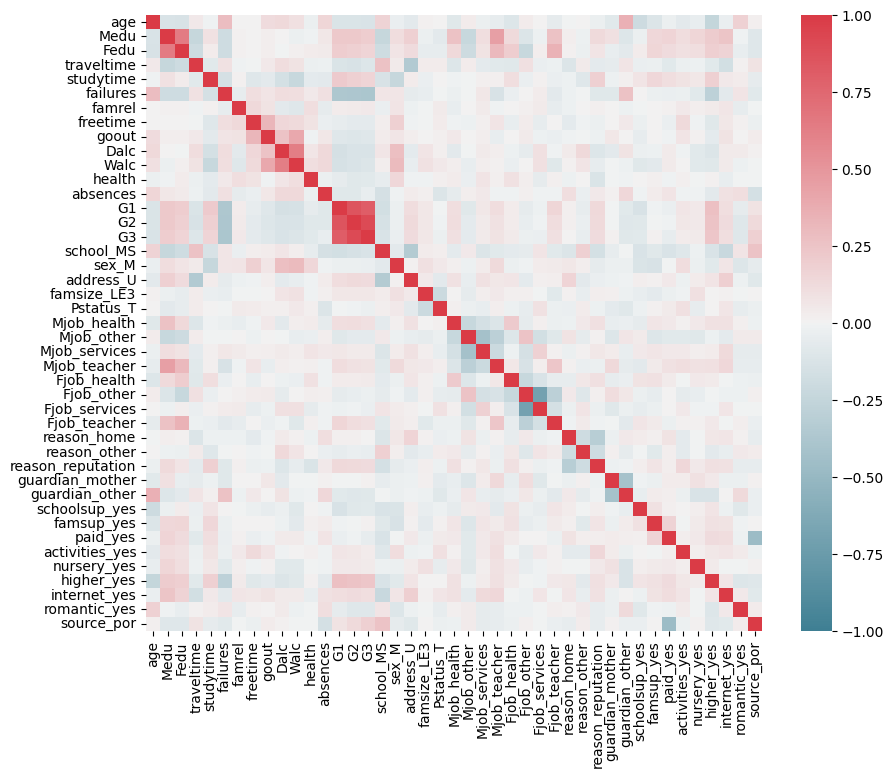

In [545]:
correlations = pd.get_dummies(merged, drop_first=True)

f, ax = plt.subplots(figsize=(10, 8))
corr = correlations.select_dtypes(exclude=['object', 'string']).corr()
sns.heatmap(corr,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1.0, vmax=1.0,
    square=True, ax=ax
)

Nous pouvons constater que les notes du 3ème trimestre sont en premier lieu corrélées aux notes reçues lors des deuxième et troisième trimestres.

Elles sont également négativement corrélées au nombre de redoublement (plus un élève aura redoublé, plus sa note du 3ème trimestre sera basse).

Nous retrouvons quelques corélations plus faibles avec le niveau d'éducation de la mère, le niveau d'éducation du père, le temps d'étude hebdomadaire, et la qualité des relations familliales.

Il semble donc que les notes passées d'un élève, ses redoublements, ainsi que son contexte familiale soient les meilleures clés de compréhension de sa réussite scolaire à venir.

## Valeurs aberrantes

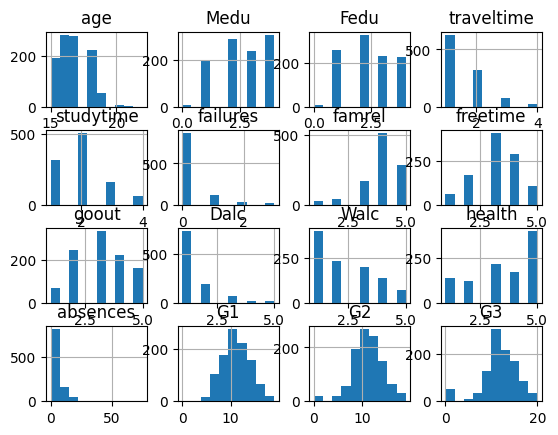

In [546]:
merged.hist()
plt.show()

### Évaluation de la normalité de G1

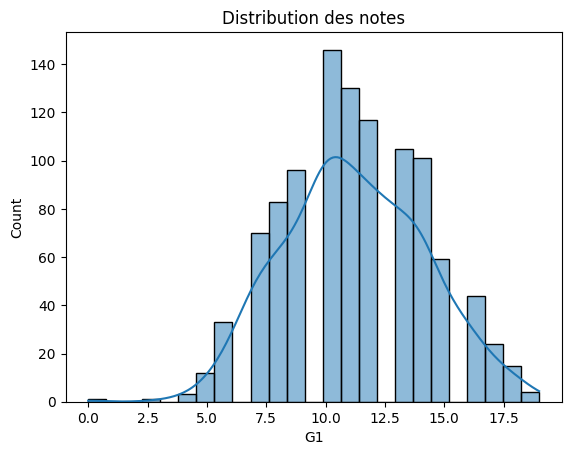

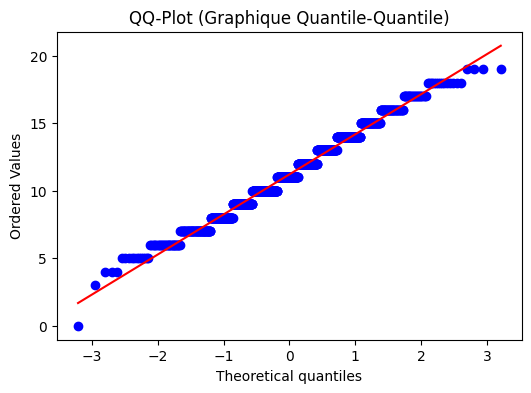

Statistique de test : 0.9862
P-value : 0.0000
Skewness : 0.07781045328592576
Kurtosis : -0.33317505703584827


In [547]:
def check_normality(data):
    sns.histplot(data, kde=True) # kde=True ajoute la courbe
    plt.title('Distribution des notes')
    plt.show()

    plt.figure(figsize=(6, 4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot (Graphique Quantile-Quantile)")
    plt.show()

    # --- B. Méthode Statistique : Test de Shapiro-Wilk ---
    statistique, p_value = stats.shapiro(data)

    print(f"Statistique de test : {statistique:.4f}")
    print(f"P-value : {p_value:.4f}")

    skewness = skew(data)
    kurtosis_result = kurtosis(data)

    print(f"Skewness : {skewness}")
    print(f"Kurtosis : {kurtosis_result}")

check_normality(merged['G1'])

### Évaluation de la normalité de G2

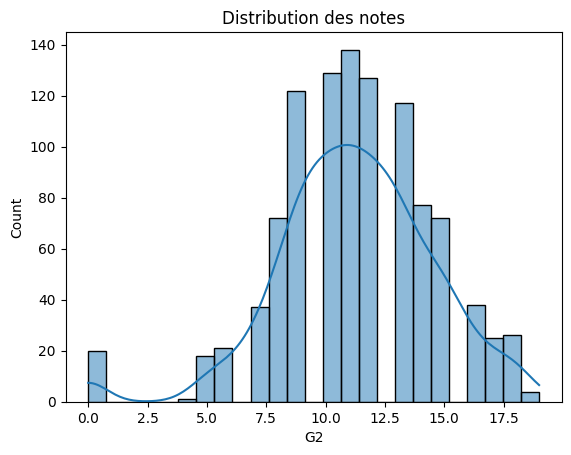

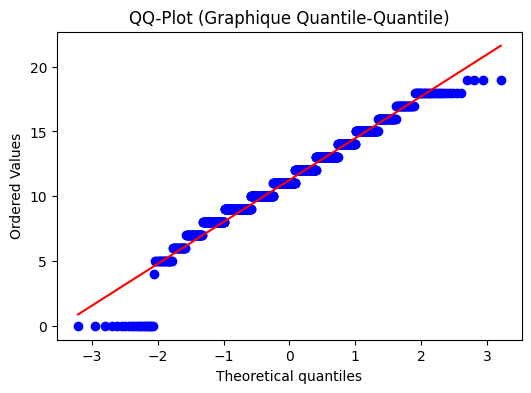

Statistique de test : 0.9638
P-value : 0.0000
Skewness : -0.4966424483539426
Kurtosis : 1.3234889885178935


In [548]:
check_normality(merged['G2'])

### Évaluation de la normalité de G3

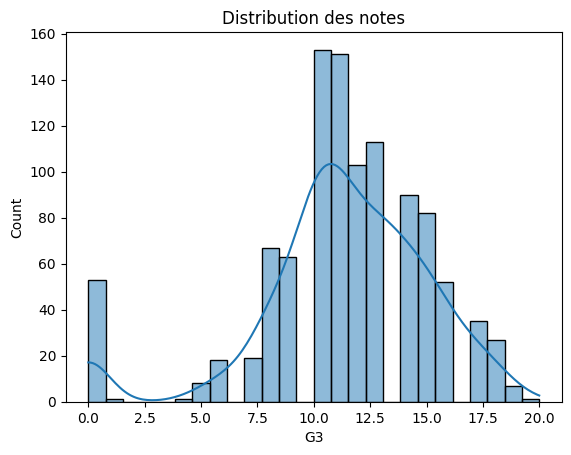

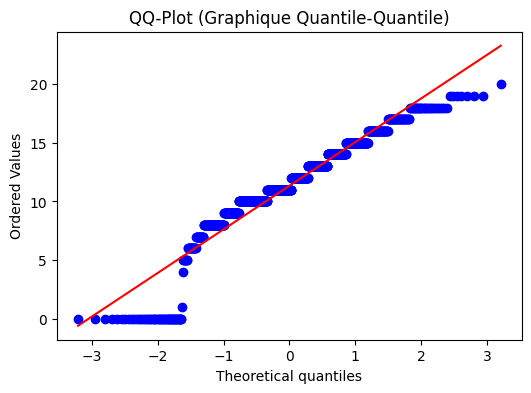

Statistique de test : 0.9183
P-value : 0.0000
Skewness : -0.984547477976957
Kurtosis : 1.730235023081005


In [549]:
check_normality(merged['G3'])

### Boîtes à moustaches

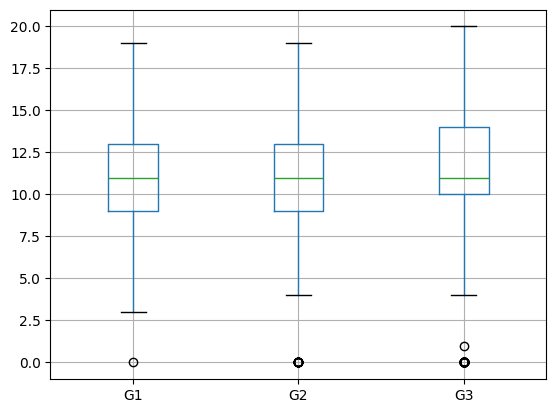

In [550]:
ax = merged.boxplot(column=["G1", "G2", "G3"])
ax.set_xticks(ax.get_xticks())  # Ensure rotation is applied to all ticks
ax.set_xticklabels(ax.get_xticklabels())
plt.show()

### Conclusion

Les colonnes G1, G2, et G3 ne suivent pas rigoureusement des lois normales au sens mathématique, mais l'allure graphique en cloche et la symétrie globale permettent de les considérer comme telles dans la pratique. Grâce à la taille importante de l'échantillon, le Théorème Central Limite s'applique, rendant les modèles robustes à ces légers écarts.

Cependant, ces distributions sont biaisées par des valeurs aberrantes égales à 0, particulièrement sur les colonnes G2 et G3. Il est donc recommandé d'exclure ces observations. En effet, une moyenne de 0/20 est peu représentative d'un niveau académique réel ; il s'agit plus probablement d'erreurs de saisie ou d'élèves absents, qui constituent une catégorie à part que nous ne pouvons pas traiter ici.

## 5.MODÉLISATION

Nous allons maintenant entraîner une régression linéaire, un arbre de décision, et une forêt aléatoire pour chacun des scénarios suivants :

1. Entraînement sur le corpus de données nettoyé
2. Entraînement sur le corpus de données mis en conformité RGPD et AI Act
3. Entraînement sur le corpus conforme, en retirant la note du second trimestre
4. Entraînement sur le corpus conforme, en retirant la note du premier et du deuxième trimestre

Cette approche nous permettra de mesurer l'impact des données sur la performance des modèles, et de choisir le plus adapté à notre situation.

In [551]:
def cross_val(modele, X, y, cv=5, scoring='accuracy'):
    scores = cross_val_score(modele, X, y, cv=cv, scoring=scoring)
    
    # Calcul des statistiques
    moyenne = scores.mean()
    ecart_type = scores.std()
    
    print("\n")
    print(f"--- Résultats Validation Croisée ({scoring}) ---")
    print(f"Scores individuels : {scores}")
    print(f"Moyenne : {moyenne:.4f}")
    print(f"Écart-type : {ecart_type:.4f} (stabilité du modèle)")
    print("-----------------------------------------------")

In [552]:
categorical_cols = [
    'school', 'sex', 'address', 'famsize', 'Pstatus', 
    'Mjob', 'Fjob', 'reason', 'guardian', 
    'schoolsup', 'famsup', 'paid', 'activities', 
    'nursery', 'higher', 'internet', 'romantic', 'source'
]

def create_and_evaluate_regression(df):
    df_clone = df.copy()

    existing_cat_cols = [col for col in categorical_cols if col in df_clone.columns]
    ready = pd.get_dummies(df_clone, columns=existing_cat_cols, drop_first=True)

    X = ready.drop('G3', axis=1) # On enlève la cible des features
    y = ready['G3']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    r2_train = r2_score(y_train, y_train_pred)

    y_pred = model.predict(X_test)

    r2_eval = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    actual_pass = y_test >= 10
    pred_pass = y_pred >= 10
    
    pass_fail_accuracy = np.mean(actual_pass == pred_pass)
    

    print("R2 train:", r2_train)
    print("R2 test:", r2_eval)
    print("RMSE:", rmse)
    print(f"Taux de bonnes classifications (Seuil 10/20) : {pass_fail_accuracy:.2%}")
    
    cross_val(model, X, y, 5, 'neg_mean_squared_log_error')
    
    return model, r2_eval, rmse, pass_fail_accuracy, y_pred


In [553]:
def create_and_evaluate_classification(df):
    df_clone = df.copy()

    df_clone['Pass'] = df_clone['G3'].apply(lambda x: 1 if x >= 10 else 0)

    existing_cat_cols = [col for col in categorical_cols if col in df_clone.columns]

    ready = pd.get_dummies(df_clone, columns=existing_cat_cols, drop_first=True)

    X = ready.drop(['G3', 'Pass'], axis=1)
    X = pd.get_dummies(X, drop_first=True)
    y = ready['Pass']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    classifier = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='gini')
    classifier.fit(X_train, y_train)

    plt.figure(figsize=(20, 10))  # On définit une grande taille d'image
    plot_tree(classifier, 
            feature_names=X.columns,  
            class_names=['Échec', 'Réussite'], # 0 et 1
            filled=True,              # Colore les noeuds selon la classe majoritaire
            rounded=True,             # Arrondit les bords des boîtes
            fontsize=10)

    plt.title("Arbre de Décision")
    plt.show()

    y_pred = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Précision (Accuracy) : {accuracy:.2f}")
    print(f"F1-Score : {f1:.2f}")

    cross_val(classifier, X, y)

    return classifier, accuracy, f1

In [554]:
def create_and_evaluate_random_forest(df):
    df_clone = df.copy()

    # Création de la target (comme dans votre exemple)
    df_clone['Pass'] = df_clone['G3'].apply(lambda x: 1 if x >= 10 else 0)

    # Gestion des colonnes catégoriques
    # Note : Assurez-vous que la liste 'categorical_cols' est définie dans votre code global
    existing_cat_cols = [col for col in categorical_cols if col in df_clone.columns]
    
    ready = pd.get_dummies(df_clone, columns=existing_cat_cols, drop_first=True)

    X = ready.drop(['G3', 'Pass'], axis=1)
    X = pd.get_dummies(X, drop_first=True)
    y = ready['Pass']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- CHANGEMENT ICI : Utilisation de RandomForestClassifier ---
    # n_estimators=100 : Le nombre d'arbres dans la forêt
    classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    classifier.fit(X_train, y_train)

    # --- VISUALISATION ---
    # On ne peut pas afficher toute la forêt, on affiche donc le premier arbre
    plt.figure(figsize=(20, 10))
    plot_tree(classifier.estimators_[0],  # On sélectionne le 1er arbre de la forêt
            feature_names=X.columns,  
            class_names=['Échec', 'Réussite'],
            filled=True,              
            rounded=True,             
            fontsize=10,
            max_depth=3) # On limite la profondeur de l'affichage pour que ce soit lisible

    plt.title("Visualisation d'un seul arbre de la Random Forest")
    plt.show()

    y_pred = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Précision Random Forest (Accuracy) : {accuracy:.2f}")
    print(f"F1-Score : {f1:.2f}")

    cross_val(classifier, X, y)

    return classifier, accuracy, f1

## Scénario 1 – Toutes les variables disponibles

### Nettoyage des données

Nous devons supprimer les valeurs aberrantes des colonnes G1, G2 et G3.

Étant donné qu'il n'y a pas de valeurs manquantes, nous n'aurons pas à définir un protocole de remplacement cette fois-ci.

In [555]:
cleaned = merged.copy()

cleaned = cleaned.drop_duplicates()

threshold = 1.5

def find_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    outliers = cleaned[(col < Q1 - threshold * IQR) | (col > Q3 + threshold * IQR)]
    return outliers

g1_outliers = find_outliers(cleaned["G1"])
cleaned = cleaned.drop(g1_outliers.index)

g2_outliers = find_outliers(cleaned["G2"])
cleaned = cleaned.drop(g2_outliers.index)

g3_outliers = find_outliers(cleaned["G3"])
cleaned = cleaned.drop(g3_outliers.index)

cleaned.to_csv("./data/cleaned.csv", index=False)

cleaned.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000
mean,16.690928,2.627637,2.406118,1.514768,1.979958,0.226793,3.945148,3.200422,3.141350,1.498945,2.285865,3.550633,4.699367,11.415612,11.617089,11.957806
std,1.237585,1.127348,1.096526,0.721369,0.833954,0.606407,0.920922,1.037787,1.132723,0.924270,1.281635,1.426321,6.342172,2.875129,2.830667,2.896729
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,5.000000,4.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,10.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,3.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Entraînement et évaluation du modèle de régression

In [556]:
print("Régression linéaire - Toutes les données")
regression_1, r2_1, rmse_1, pf_accuracy_1, _ = create_and_evaluate_regression(cleaned)

Régression linéaire - Toutes les données
R2 train: 0.9261057847730374
R2 test: 0.8855829383261606
RMSE: 0.9097443082047972
Taux de bonnes classifications (Seuil 10/20) : 87.37%


--- Résultats Validation Croisée (neg_mean_squared_log_error) ---
Scores individuels : [-0.00710198 -0.00517895 -0.00472407 -0.00619682 -0.00628052]
Moyenne : -0.0059
Écart-type : 0.0008 (stabilité du modèle)
-----------------------------------------------


### Entraînement du modèle de classification

Classification - Toutes les données


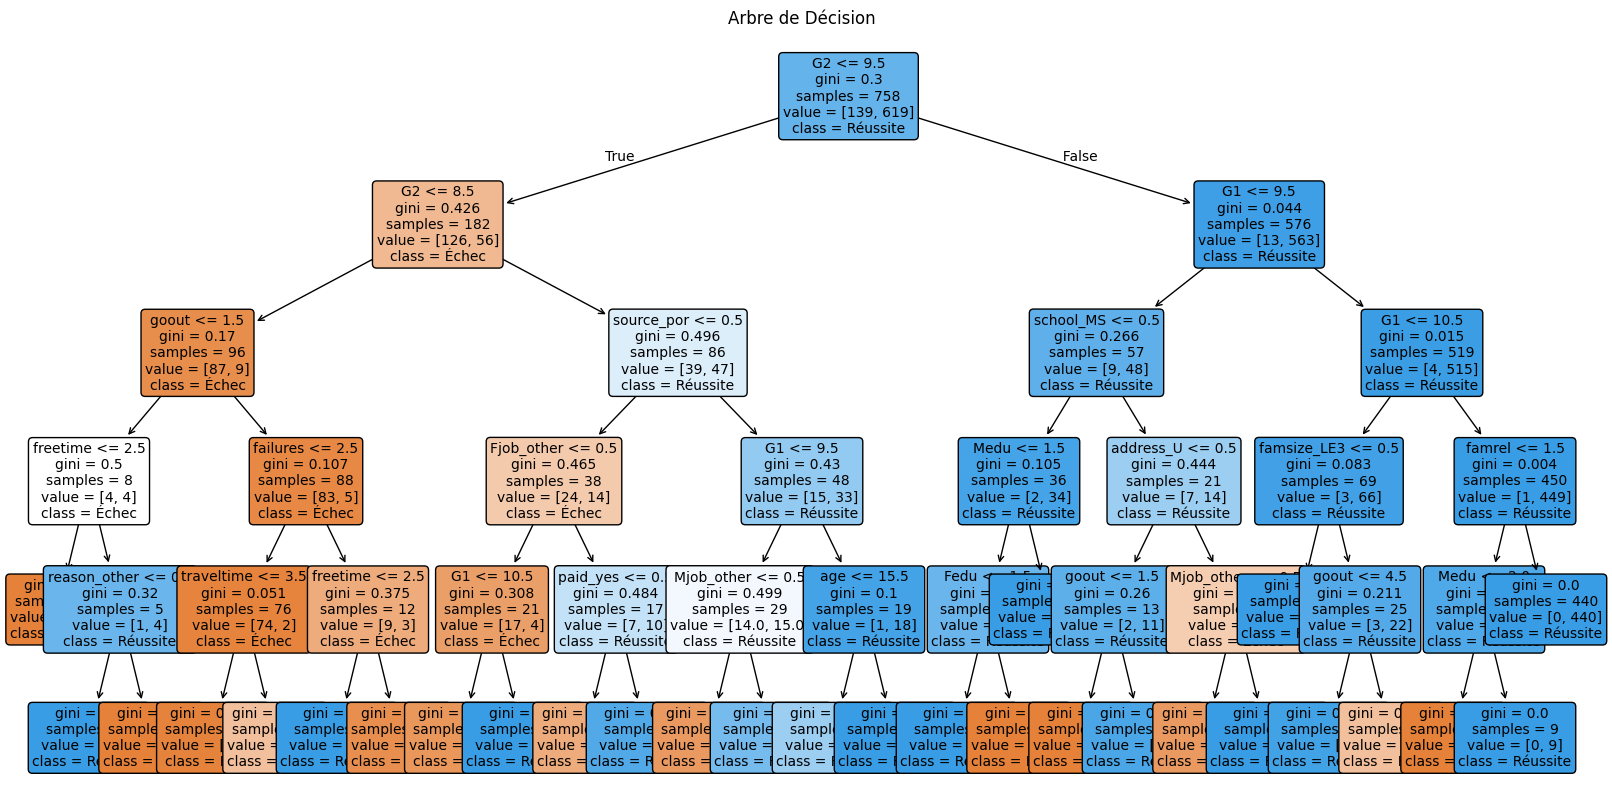

Précision (Accuracy) : 0.89
F1-Score : 0.94


--- Résultats Validation Croisée (accuracy) ---
Scores individuels : [0.87894737 0.93157895 0.91052632 0.91005291 0.7989418 ]
Moyenne : 0.8860
Écart-type : 0.0467 (stabilité du modèle)
-----------------------------------------------


In [557]:
print("Classification - Toutes les données")
classification_1, accuracy_1, tree_f1_1 = create_and_evaluate_classification(cleaned)

### Entraînement de la forêt aléatoire

Forêt Aléatoire - Toutes les données


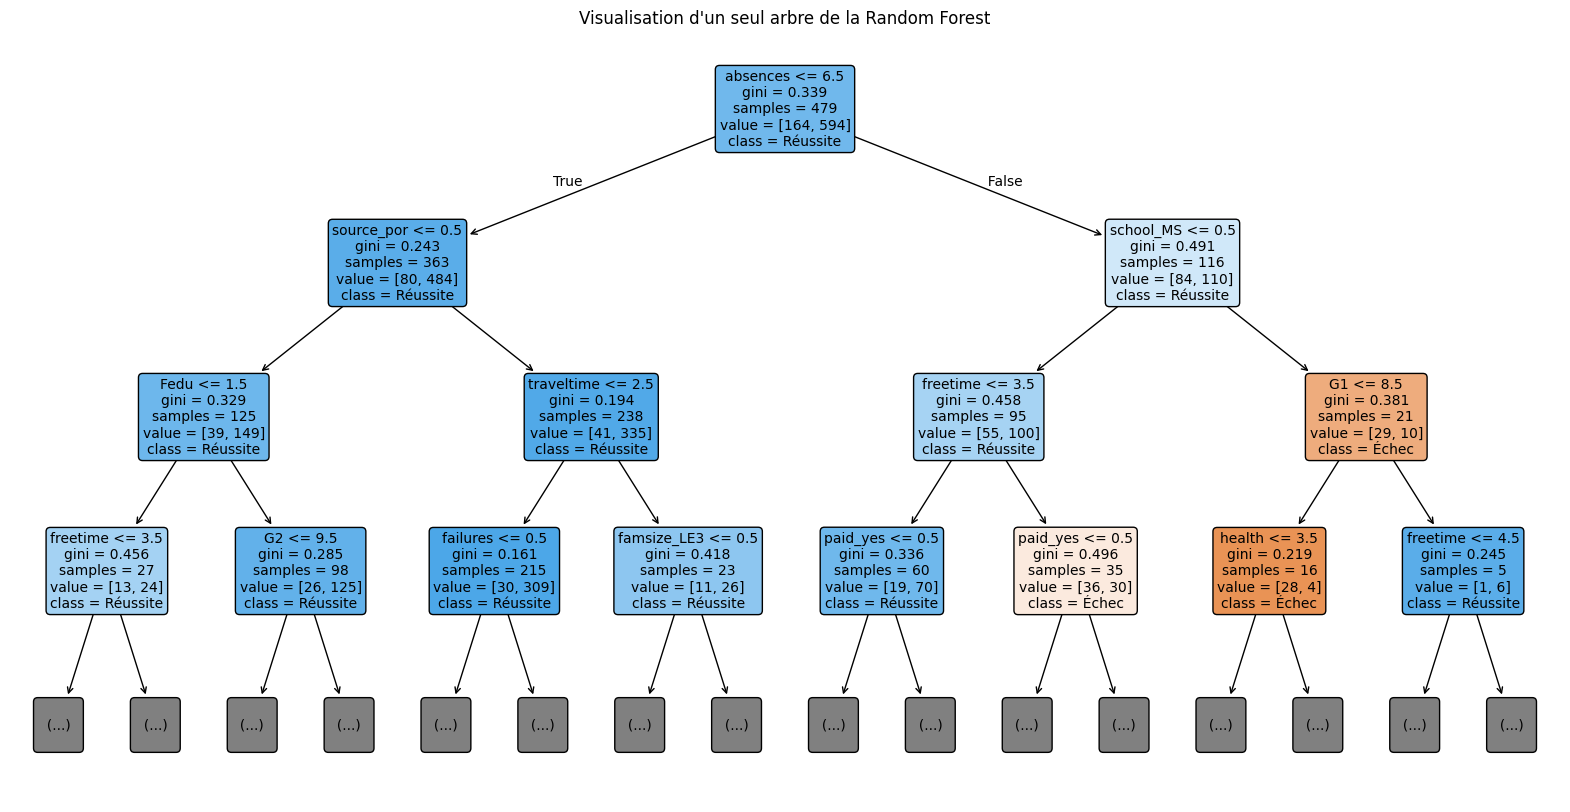

Précision Random Forest (Accuracy) : 0.91
F1-Score : 0.95


--- Résultats Validation Croisée (accuracy) ---
Scores individuels : [0.91052632 0.93684211 0.91578947 0.91534392 0.85714286]
Moyenne : 0.9071
Écart-type : 0.0266 (stabilité du modèle)
-----------------------------------------------


In [558]:
print("Forêt Aléatoire - Toutes les données")
random_forest_1, rf_accuracy_1, rf_f1_1 = create_and_evaluate_random_forest(cleaned)

## Scénario 2 – Sans variables sensibles

### Mise en conformité du jeu de données

Nous avons identifié certaines variables dans le jeu de données qui pourraient introduire des comportements discriminatoires :

- `school` : Risque de discrimination géographique.
- `sex` : Risque de discrimination directe. Un élève pourrait être favorisé ou pénalisé uniquement à cause de son genre.
- `age` : Un élève plus âgé (ayant redoublé) pourrait être jugé "moins capable".
- `health` : Donnée sensible du point de vue du RGPD.
- `dalc` : Consommation d'alcool, donnée pouvant être considérée comme sensible du point de vue du RGPD.
- `walc` : Consommation d'alcool, donnée pouvant être considérée comme sensible du point de vue du RGPD.
- `romantic` : Donnée strictement personnelle — que l'établissement ne devrait même pas posséder en premier lieu — et sans lien apparent avec ce que l'on cherche à prédire.
- `goout` : Donnée strictement personnelle — que l'établissement ne devrait même pas posséder en premier lieu — et sans lien apparent avec ce que l'on cherche à prédire. 
- `famrel` : Qualité des relations familiales. Extrêmement subjectif et intrusif.
- `Pstatus` : Statut marital des parents. Information privée sur la vie des parents. 
- `Mjob` : Métier du père. Pourrait introduire des biais vis-à-vis du déterminisme social.
- `Fjob` : Métier de la mère. Pourrait introduire des biais vis-à-vis du déterminisme social.
- `Medu` : Niveau d'éducation du père. Pourrait introduire des biais vis-à-vis du déterminisme social. 
- `Fedu` : Niveu d'éducation de la mère. Pourrait introduire des biais vis-à-vis du déterminisme social.
- `address` : Aucun rapport apparent avec ce que l'on cherche à prédire.

In [559]:
cols_to_drop = [
   'school', 'sex', 'age', 'health', 'Dalc', 'Walc', 'romantic', 'goout', 'famrel', 'Pstatus', 'Mjob', 'Fjob', 'Medu', 'Fedu', 'address'
]

# On retire uniquement les colonnes présentes dans le df
existing_cols_to_drop = [c for c in cols_to_drop if c in cleaned.columns]
ethical = cleaned.drop(existing_cols_to_drop, axis=1)

ethical.to_csv('./data/ethical.csv', index=False)

ethical.describe()

,traveltime,studytime,failures,freetime,absences,G1,G2,G3
count,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000
mean,1.514768,1.979958,0.226793,3.200422,4.699367,11.415612,11.617089,11.957806
std,0.721369,0.833954,0.606407,1.037787,6.342172,2.875129,2.830667,2.896729
min,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,5.000000,4.000000
25%,1.000000,1.000000,0.000000,3.000000,0.000000,9.000000,10.000000,10.000000
50%,1.000000,2.000000,0.000000,3.000000,3.000000,11.000000,11.000000,12.000000
75%,2.000000,2.000000,0.000000,4.000000,6.000000,13.000000,13.000000,14.000000
max,4.000000,4.000000,3.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Entraînement et évaluation du modèle de régression

In [560]:
print("Régression linéaire - Données conformes")
regression_2, r2_2, rmse_2, pf_accuracy_2, y_pred_regression_2 = create_and_evaluate_regression(ethical)

Régression linéaire - Données conformes
R2 train: 0.9223800101300405
R2 test: 0.8900607006584272
RMSE: 0.89176502280241
Taux de bonnes classifications (Seuil 10/20) : 87.37%


--- Résultats Validation Croisée (neg_mean_squared_log_error) ---
Scores individuels : [-0.00691106 -0.00490883 -0.00463475 -0.00589502 -0.00603277]
Moyenne : -0.0057
Écart-type : 0.0008 (stabilité du modèle)
-----------------------------------------------


### Entraînement et évaluation du modèle de classification

Classification - Données conformes


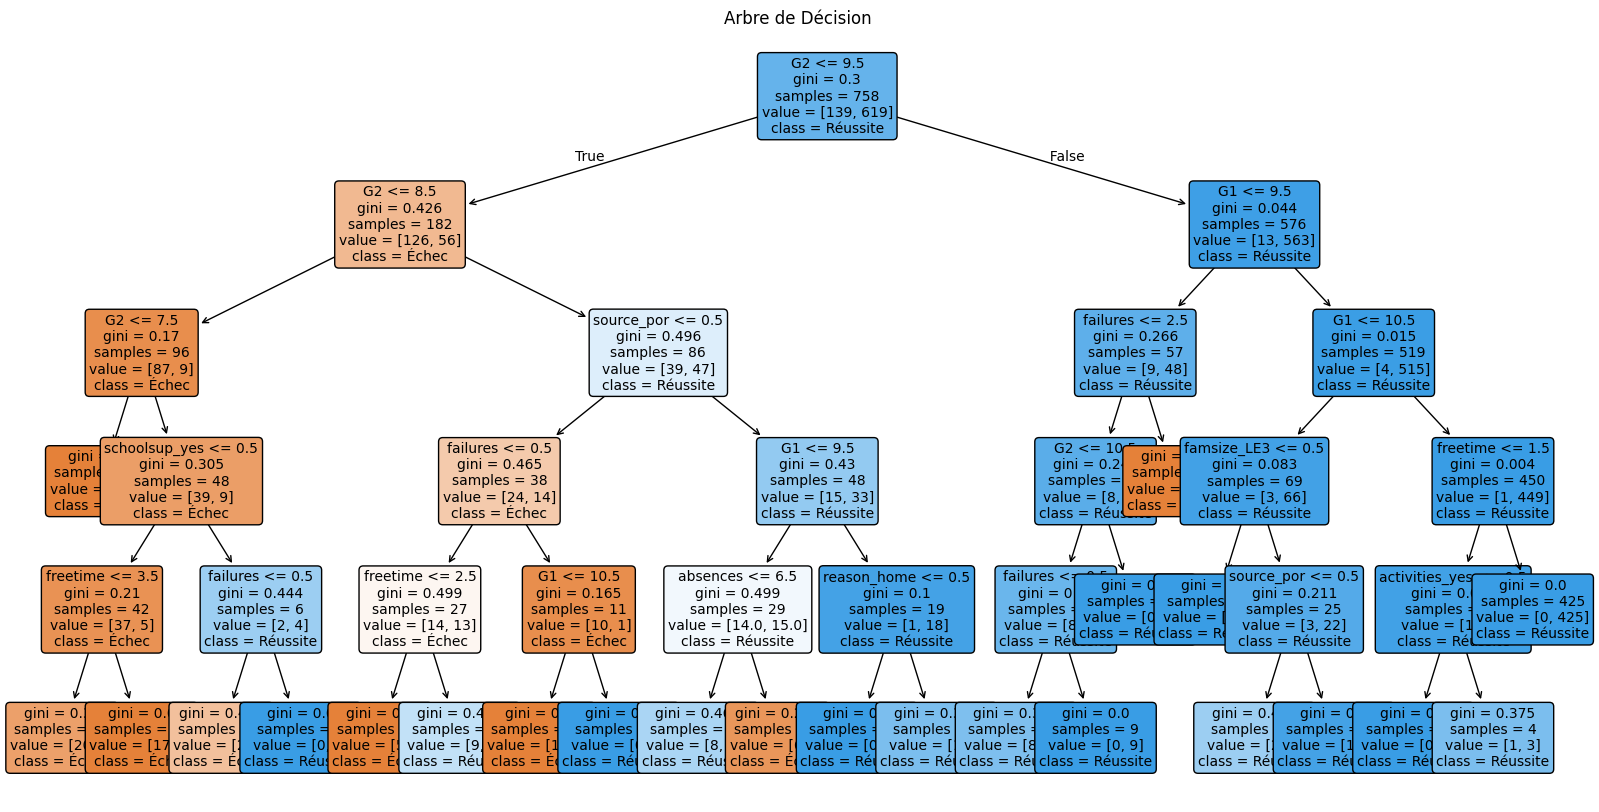

Précision (Accuracy) : 0.93
F1-Score : 0.96


--- Résultats Validation Croisée (accuracy) ---
Scores individuels : [0.84736842 0.95789474 0.92105263 0.92592593 0.86772487]
Moyenne : 0.9040
Écart-type : 0.0405 (stabilité du modèle)
-----------------------------------------------


In [561]:
print("Classification - Données conformes")
classifier_2, accuracy_2, tree_f1_2 = create_and_evaluate_classification(ethical)

### Entraînement et évaluation de la forêt aléatoire

Forêt Aléatoire - Données conformes


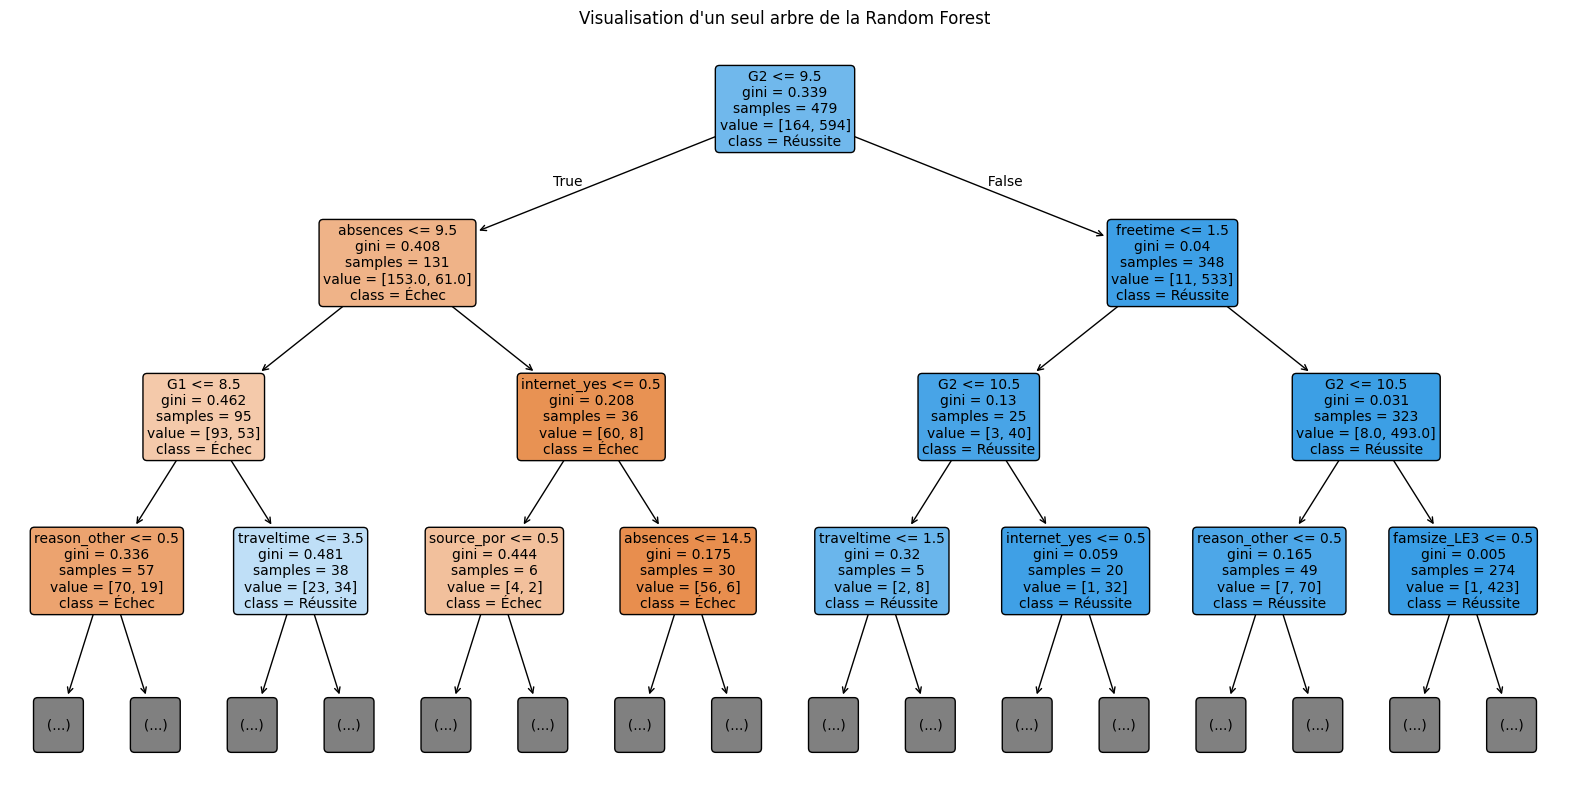

Précision Random Forest (Accuracy) : 0.93
F1-Score : 0.96


--- Résultats Validation Croisée (accuracy) ---
Scores individuels : [0.9        0.94210526 0.93157895 0.91534392 0.88359788]
Moyenne : 0.9145
Écart-type : 0.0211 (stabilité du modèle)
-----------------------------------------------


In [562]:
print("Forêt Aléatoire - Données conformes")
random_forest_2, rf_accuracy_2, rf_f1_2 = create_and_evaluate_random_forest(ethical)

## Scénario 3 – Sans variables sensibles + sans G2

### Entraînement et évaluation du modèle de régression

In [563]:
ethical_no_g2 = ethical.drop('G2', axis=1, inplace=False)

print("Régression linéaire - Données conformes sans G2")
regression_3, r2_3, rmse_3, pf_accuracy_3, y_pred_regression_3 = create_and_evaluate_regression(ethical_no_g2)

Régression linéaire - Données conformes sans G2
R2 train: 0.8076234598595305
R2 test: 0.7650993179418415
RMSE: 1.3035151729984789
Taux de bonnes classifications (Seuil 10/20) : 87.89%


--- Résultats Validation Croisée (neg_mean_squared_log_error) ---
Scores individuels : [-0.02082443 -0.01502586 -0.01087718 -0.01260975 -0.01042905]
Moyenne : -0.0140
Écart-type : 0.0038 (stabilité du modèle)
-----------------------------------------------


### Entraînement et évaluation du modèle de classification

Classification - Données conformes sans G2


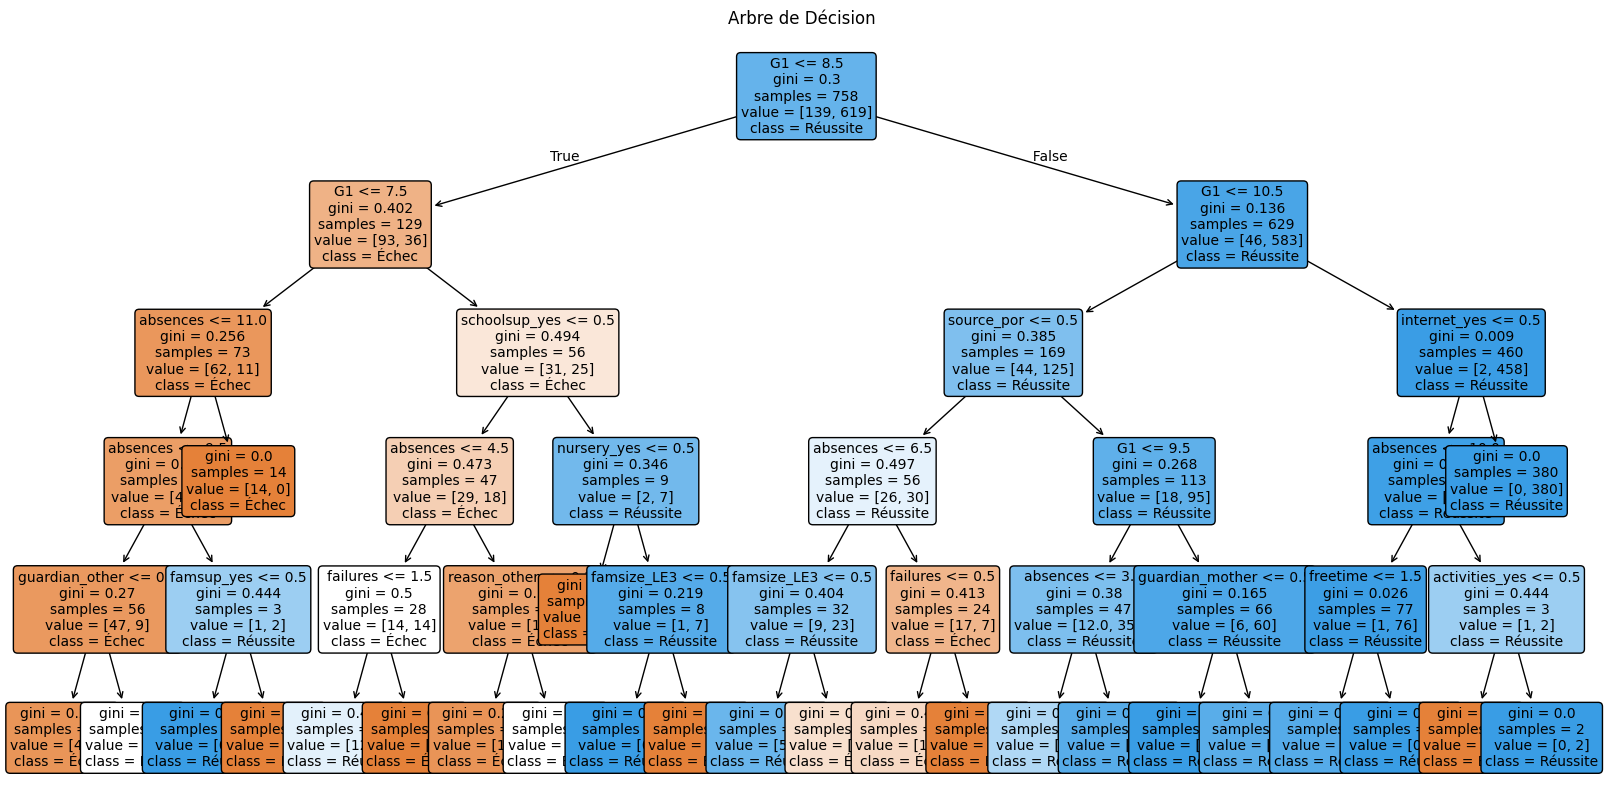

Précision (Accuracy) : 0.89
F1-Score : 0.93


--- Résultats Validation Croisée (accuracy) ---
Scores individuels : [0.78947368 0.92631579 0.85789474 0.89417989 0.85714286]
Moyenne : 0.8650
Écart-type : 0.0457 (stabilité du modèle)
-----------------------------------------------


In [564]:
print("Classification - Données conformes sans G2")
classifier_3, accuracy_3, tree_f1_3 = create_and_evaluate_classification(ethical_no_g2)

### Entraînement et évaluation de la forêt aléatoire

Forêt Aléatoire - Données conformes sans G2


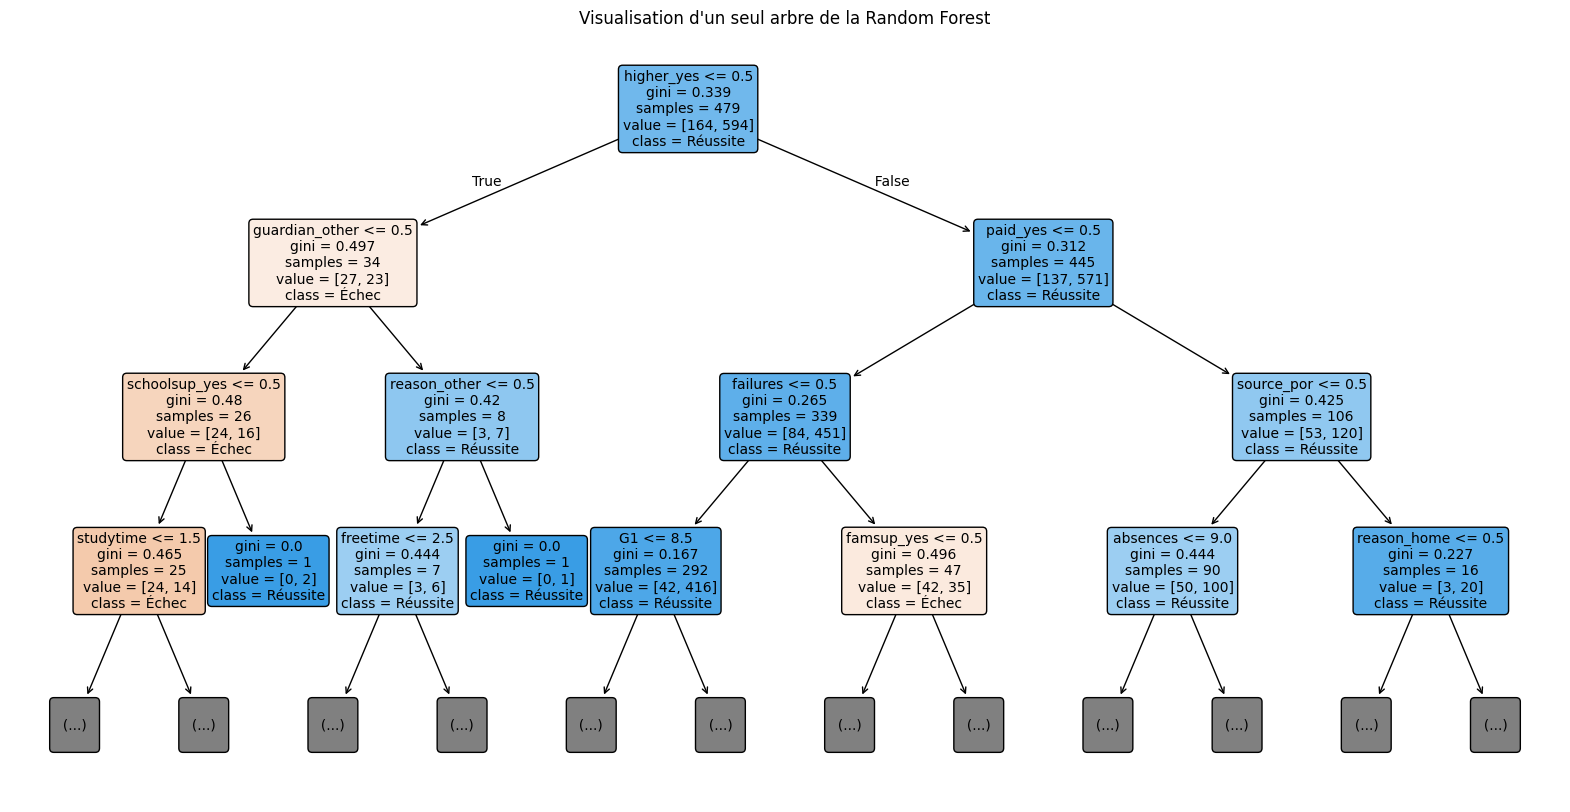

Précision Random Forest (Accuracy) : 0.86
F1-Score : 0.92


--- Résultats Validation Croisée (accuracy) ---
Scores individuels : [0.85789474 0.91052632 0.88947368 0.8994709  0.86772487]
Moyenne : 0.8850
Écart-type : 0.0196 (stabilité du modèle)
-----------------------------------------------


In [565]:
print("Forêt Aléatoire - Données conformes sans G2")
random_forest_3, rf_accuracy_3, rf_f1_3 = create_and_evaluate_random_forest(ethical_no_g2)

## Scénario 4 – Sans variables sensibles + sans G1 et G2

### Entraînement et évaluation du modèle

In [566]:
ethical_no_g2_g1 = ethical.drop(['G2', 'G1'], axis=1, inplace=False)

print("Régression linéaire - Données conformes sans G2 ni G1")
regression_4, r2_4, rmse_4, pf_accuracy_4, _ = create_and_evaluate_regression(ethical_no_g2_g1)

Régression linéaire - Données conformes sans G2 ni G1
R2 train: 0.2503858424089723
R2 test: 0.23776263295670397
RMSE: 2.348113413869676
Taux de bonnes classifications (Seuil 10/20) : 80.53%


--- Résultats Validation Croisée (neg_mean_squared_log_error) ---
Scores individuels : [-0.07150641 -0.05356027 -0.02661258 -0.02979032 -0.04437669]
Moyenne : -0.0452
Écart-type : 0.0164 (stabilité du modèle)
-----------------------------------------------


### Entraînement et évaluation du modèle de classification

Classification - Données conformes sans G2 ni G1


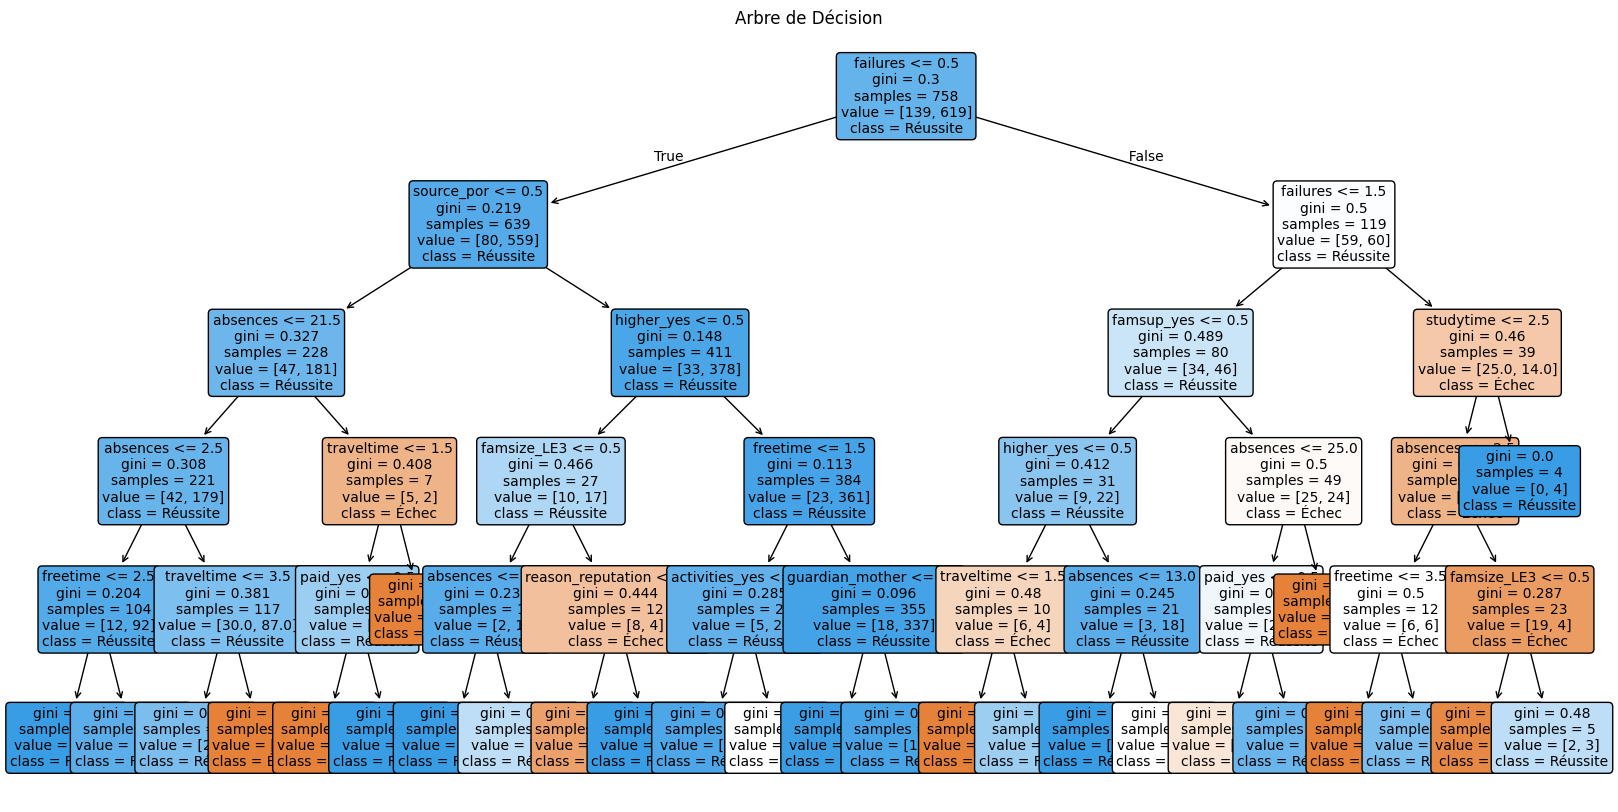

Précision (Accuracy) : 0.79
F1-Score : 0.88


--- Résultats Validation Croisée (accuracy) ---
Scores individuels : [0.78421053 0.82631579 0.82631579 0.82539683 0.80952381]
Moyenne : 0.8144
Écart-type : 0.0164 (stabilité du modèle)
-----------------------------------------------


In [567]:
print("Classification - Données conformes sans G2 ni G1")
classifier_4, accuracy_4, tree_f1_4 = create_and_evaluate_classification(ethical_no_g2_g1)

### Entraînement et évaluation de la forêt aléatoire

Forêt Aléatoire - Données conformes sans G2 ni G1


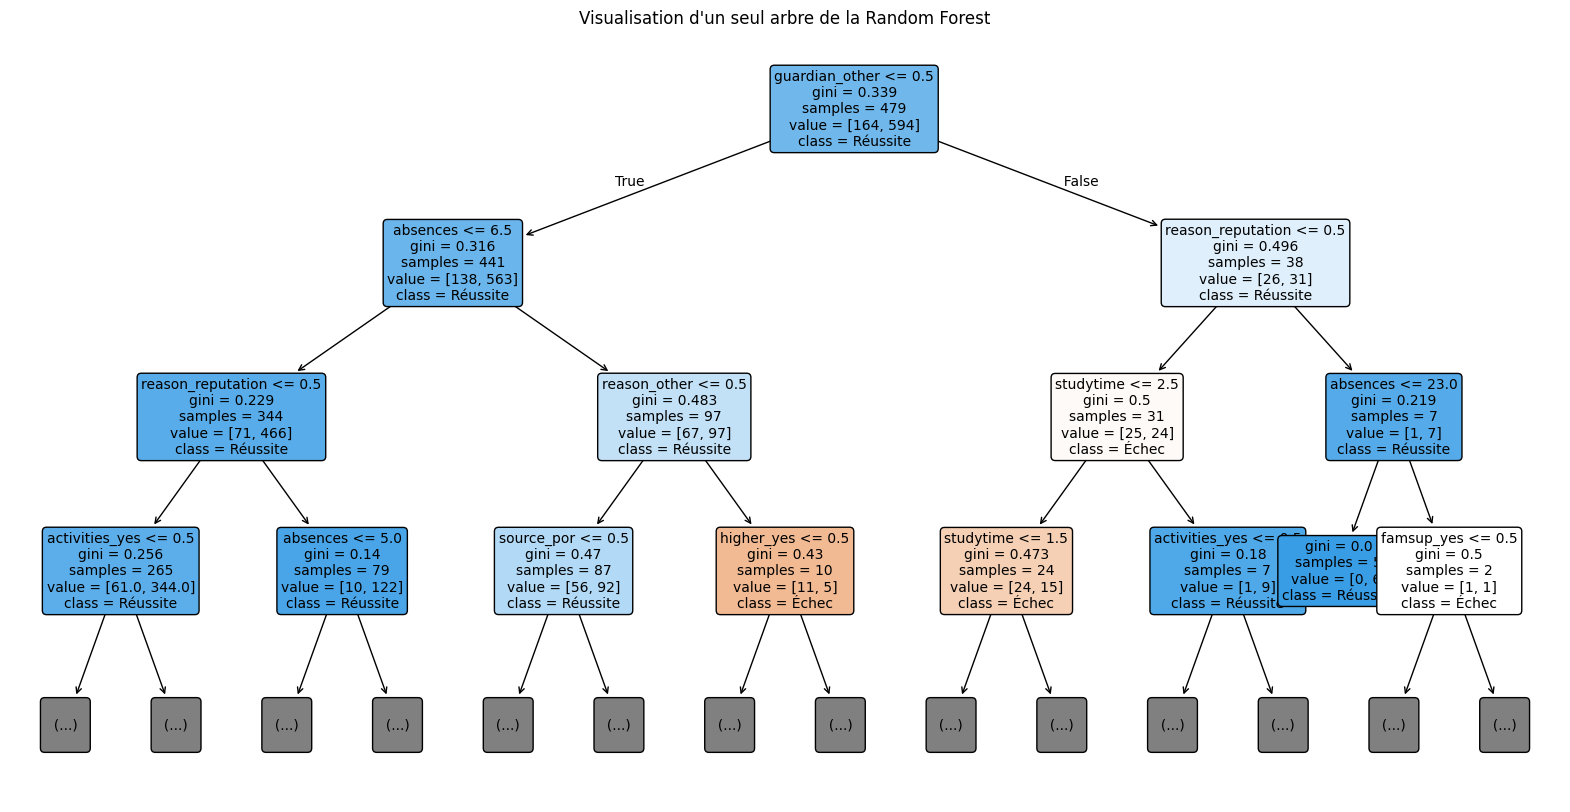

Précision Random Forest (Accuracy) : 0.84
F1-Score : 0.91


--- Résultats Validation Croisée (accuracy) ---
Scores individuels : [0.8        0.81052632 0.81578947 0.83068783 0.82010582]
Moyenne : 0.8154
Écart-type : 0.0102 (stabilité du modèle)
-----------------------------------------------


In [568]:
print("Forêt Aléatoire - Données conformes sans G2 ni G1")
random_forest_4, rf_accuracy_4, rf_f1_4 = create_and_evaluate_random_forest(ethical_no_g2_g1)

## Conclusion

### Comparatif

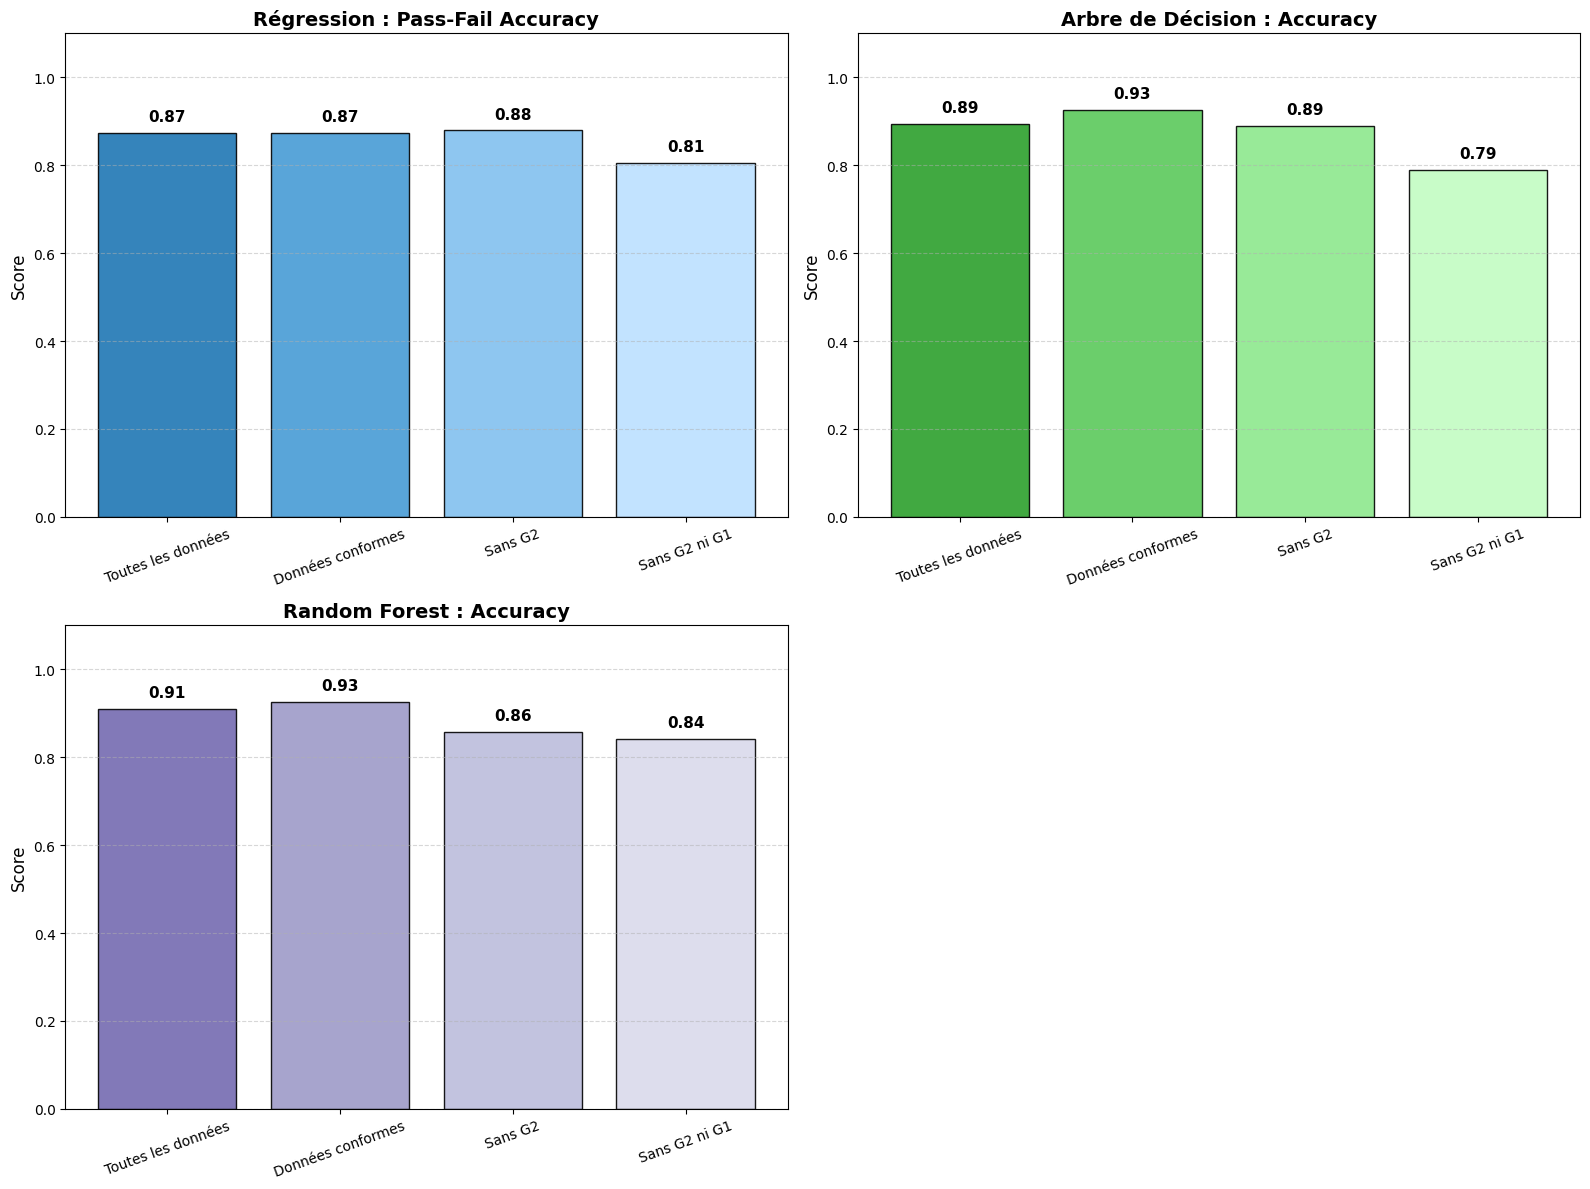

In [569]:
# --- 2. Définition des scénarios ---
models = ['Toutes les données', 'Données conformes', 'Sans G2', 'Sans G2 ni G1']

# On suppose que ces variables sont définies précédemment
pf_scores = [pf_accuracy_1, pf_accuracy_2, pf_accuracy_3, pf_accuracy_4]
acc_scores = [accuracy_1, accuracy_2, accuracy_3, accuracy_4]
rf_scores = [rf_accuracy_1, rf_accuracy_2, rf_accuracy_3, rf_accuracy_4]

# --- 3. Création du graphique ---
# On crée une grille 2x2 (2 lignes, 2 colonnes)
# figsize=(16, 12) : On augmente la hauteur car il y a maintenant 2 étages
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Pour simplifier l'accès, on "aplatit" le tableau d'axes ou on les nomme directement
ax1 = axs[0, 0] # En haut à gauche
ax2 = axs[0, 1] # En haut à droite
ax3 = axs[1, 0] # En bas à gauche
ax4 = axs[1, 1] # En bas à droite (sera vide)

# ==============================================================================
# Graphique 1 : RÉGRESSION (Bleu) -> En haut à gauche
# ==============================================================================
colors_r2 = ['#1f77b4', '#479bd5', '#82c0ef', '#bce0ff'] 
bars1 = ax1.bar(models, pf_scores, color=colors_r2, edgecolor='black', alpha=0.9)

ax1.set_title('Régression : Pass-Fail Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.tick_params(axis='x', rotation=20)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# ==============================================================================
# Graphique 2 : ARBRE DE DÉCISION (Vert) -> En haut à droite
# ==============================================================================
colors_acc = ['#2ca02c', '#5bc95b', '#8de88d', '#c2fcc2']
bars2 = ax2.bar(models, acc_scores, color=colors_acc, edgecolor='black', alpha=0.9)

ax2.set_title('Arbre de Décision : Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.tick_params(axis='x', rotation=20)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# ==============================================================================
# Graphique 3 : RANDOM FOREST (Violet) -> En bas à gauche
# ==============================================================================
colors_rf = ['#756bb1', '#9e9ac8', '#bcbddc', '#dadaeb'] 
bars3 = ax3.bar(models, rf_scores, color=colors_rf, edgecolor='black', alpha=0.9)

ax3.set_title('Random Forest : Accuracy', fontsize=14, fontweight='bold')
ax3.set_ylabel('Score', fontsize=12)
ax3.set_ylim(0, 1.1)
ax3.grid(axis='y', linestyle='--', alpha=0.5)
ax3.tick_params(axis='x', rotation=20)

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# ==============================================================================
# Gestion du 4ème graphique (Vide)
# ==============================================================================
# On masque le graphique en bas à droite pour ne pas avoir un cadre vide inutile
ax4.axis('off')

# --- Affichage final ---
plt.tight_layout()
plt.show()

### Analyse

Nous pouvons tout d'abord constater que l'impact de la réduction du corpus de données n'est pas uniforme selon les types de modèles : si nous pouvons constater une baisse de performances attendue sur les deux modèles de classification pour les scénarios 3 et 4, le modèle de régression présente une exception intéressante dans la mesure où il plus performant sur le scénario 3 que sur tous les autres.

Évidemment, le modèle de régression ne prédit pas directement si un élève va réussir son année : il est fait pour prédire la note du troisième trimestre.
Son R2 est de 0.76 Comparé au R2 du modèle du 2ème scénario (0.89), nous pouvons effectivement constater qu'il y a une dégradation des performances sur la tâche de prédiction de la note. En revanche, cette dégradation entraîne paradoxalement une amélioration des performances sur la tâche de prédiction de la réussite.

Dans la mesure où dans notre cas, la réussite scolaire n'est liée qu'à la note du ttroisième trimestre (réussite si supérieure ou égale à 10), nous pouvons intuitivement expliquer ce comportement par le fait que le modèle pourrait purement et simplement sur-estimer les bons élèves, et sous-estimer les mauvais.

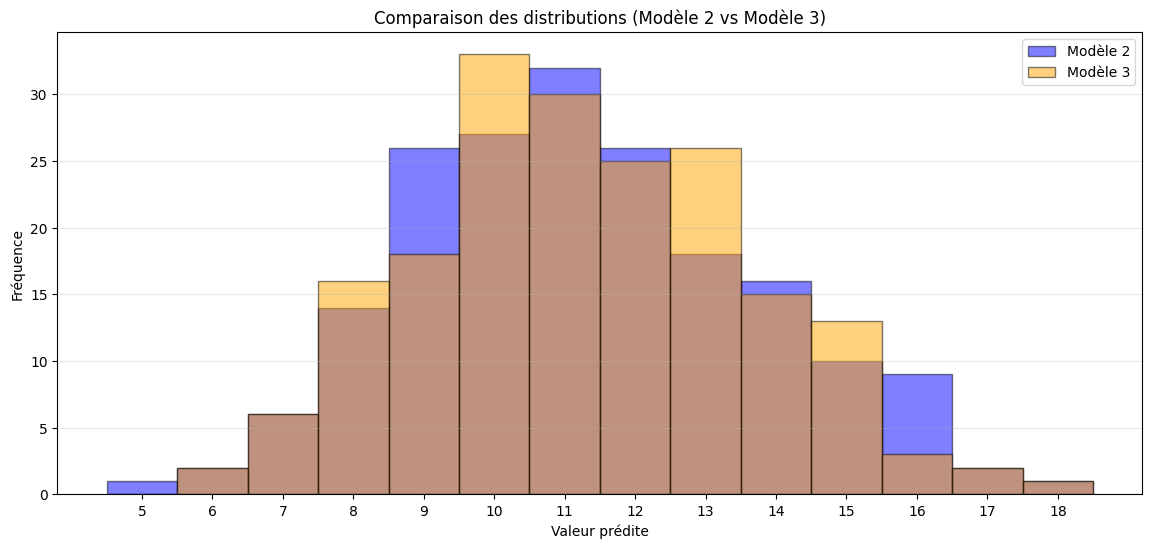

In [570]:
# 1 ligne, 2 colonnes
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

y2_clean = np.floor(y_pred_regression_2).astype(int)
y3_clean = np.floor(y_pred_regression_3).astype(int)

global_min = min(y2_clean.min(), y3_clean.min())
global_max = max(y2_clean.max(), y3_clean.max())

bins = range(global_min, global_max + 2)

plt.hist(y2_clean, bins=bins, align='left', alpha=0.5, label='Modèle 2', color='blue', edgecolor='black')
plt.hist(y3_clean, bins=bins, align='left', alpha=0.5, label='Modèle 3', color='orange', edgecolor='black')

plt.legend(loc='upper right')
plt.title("Comparaison des distributions (Modèle 2 vs Modèle 3)")
plt.xlabel("Valeur prédite")
plt.ylabel("Fréquence")
plt.grid(axis='y', alpha=0.3)

if global_max - global_min < 20:
    plt.xticks(range(global_min, global_max + 1))

plt.show()

Nous pouvons voir que les résultats du modèle 2 sont légèrement plus étalés que ceux du modèle 3. Contrairement à ce que nous disait notre intuition, le modèle 3 ni ne surestime les bons élèves, ni ne sousestime les mauvais : les résultats sont en fait regroupés vers la moyenne. 
Le modèle 3 a tendance à lisser les comportements extrêmes en concentrant les résultats autour de la moyenne, évitant ainsi les prédictions trop audacieuses aux frontières de la réussite

Nous pouvons supposer que, ne pouvant prendre en compte la note du deuxième trimestre, le modèle 3 ne peut pas tenir compte des décrochages scolaires ou des progrès ayant lieu en cours d'année, et ne peut que dessiner une tendance sur des données plus générales.

Cela nous donne une nouvelle perspective sur notre jeu de données : la note du deuxième trimestre est essentielle pour prédire correctement la note du troisième trimestre, mais elle introduit une variance (ou sensibilité) contre-productive qui dessert la classification binaire lorsque nous utilisons un modèle de régression.

Il faut noter cependant que nous n'observons pas de tel gain de performances entre les scénarios 2 et 3 sur les modèles de classification (arbres décisionnels et forêts aléatoires). 
Ce paradoxe ne s'observe donc pas sur des modèles purement orientés classification, qui savent exploiter la corrélation de G2 pour tracer une frontière de décision nette sans subir cet effet de variance.
Cela contribue à illustrer les différences de fonctionnement de ces types de modèles. 

### Quel modèle choisir ?

F1-Score Arbre de Décision (Scénario 2) : 0.9565
F1-Score Forêt Aléatoire (Scénario 2)   : 0.9568


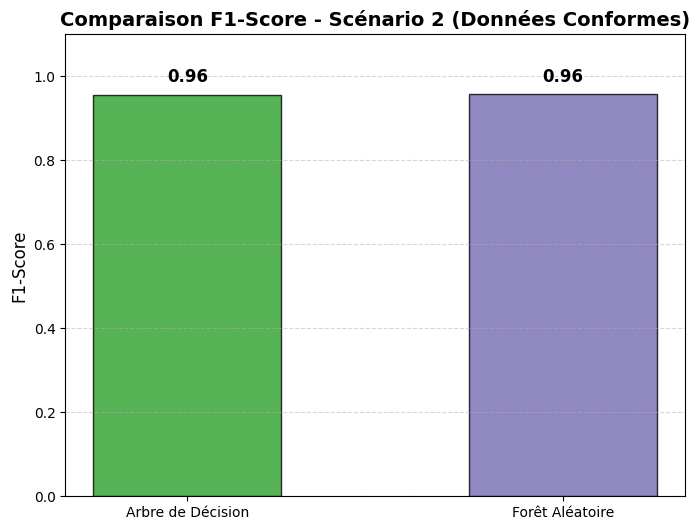

In [571]:
print(f"F1-Score Arbre de Décision (Scénario 2) : {tree_f1_2:.4f}")
print(f"F1-Score Forêt Aléatoire (Scénario 2)   : {rf_f1_2:.4f}")

plt.figure(figsize=(8, 6))
models_names = ['Arbre de Décision', 'Forêt Aléatoire']
scores = [f1_dt, f1_rf]
colors = ['#2ca02c', '#756bb1'] # Vert et Violet pour respecter votre charte graphique

bars = plt.bar(models_names, scores, color=colors, edgecolor='black', alpha=0.8, width=0.5)

plt.title('Comparaison F1-Score - Scénario 2 (Données Conformes)', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ajout des valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

Nous ne pouvons bien sûr pas utiliser les modèles du scénario 1 car leurs données d'entraînement ne sont pas conforme au RGPD, et nous pouvons également constater qu'ils ne sont pas forcément les plus performants.

Sur la simple tâche d'identifier la réussiste scolaire d'un élève, les meilleures modèles sont l'arbre de décision et la forêt aléatoire entraînés sur le jeu de données conforme et complet, qui ont tous les deux une précision de 93%.

Dans la mesure où les performances, autant sur la précision que sur le rappel, sont les mêmes et que nous sommes dans une démarche de transparence et d'explicabilité, nous privilégierons l'arbre de décision, qui a un comportement plus intelligible.

## Sauvegarde du modèle

In [572]:
joblib.dump(classifier_2, './models/model.joblib')

existing_cat_cols = [col for col in categorical_cols if col in ethical_no_g2_g1.columns]

print('Inputs:', pd.get_dummies(ethical_no_g2_g1, columns=existing_cat_cols, drop_first=True).drop(columns="G3").columns.values)

Inputs: ['traveltime' 'studytime' 'failures' 'freetime' 'absences' 'famsize_LE3'
 'reason_home' 'reason_other' 'reason_reputation' 'guardian_mother'
 'guardian_other' 'schoolsup_yes' 'famsup_yes' 'paid_yes' 'activities_yes'
 'nursery_yes' 'higher_yes' 'internet_yes' 'source_por']
